# Part 1 — OLS, Hat Matrix, Ridge Regression & VIF

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

# add root path
project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from part1.ols_implementation import ols_fit, hat_matrix, vif
from part1.ridge_lasso import ridge_fit

# Tạo Toy Data (Có ý nghĩa toán học)
np.random.seed(42)
n, p = 100, 2
X_toy = np.random.randn(n, p)
X_toy_design = np.c_[np.ones(n), X_toy]  # Thêm Intercept
true_beta = np.array([5.0, 2.0, -3.0])
y_toy = X_toy_design.dot(true_beta) + np.random.randn(n) * 1.5  # Noise ~ N(0, 1.5^2)

# chuyển thành list
X = X_toy.tolist()
X_design = X_toy_design.tolist()
y = y_toy.tolist()

print("=== Dữ liệu Toy Data ===")
print(f"Kích thước X        : {len(X)} hàng, {len(X[0])} cột")
print(
    f"Kích thước X_design : {len(X_design)} hàng, {len(X_design[0])} cột (có Intercept)"
)
print(f"Kích thước y        : {len(y)} phần tử")

---
## 1. OLS Fit — `ols_fit(X, y)`

### Lý thuyết
Ước lượng OLS tối thiểu hóa $\|y - X\beta\|^2$, cho nghiệm:
$$\hat{\beta} = (X^\top X)^{-1} X^\top y$$

### Cài đặt
Dùng Economic SVD: $X = U\Sigma V^\top$
$$\hat{\beta} = V\Sigma^{-1}U^\top y$$

Luồng gọi: `ols_fit` → `svd_solve` (utils/svd_solver.py) → `economic_svd` → **`svd_decomp`** (utils/decomposition.py)

In [3]:
# OLS
beta_hat, sigma2_hat = ols_fit(X_design, y)

# Kiem chung bang numpy.linalg.lstsq
beta_ref = np.linalg.lstsq(X_toy_design, y_toy, rcond=None)[0]

# Tính sigma^2 tham chiếu: RSS / (n - k)
y_hat_ref = X_toy_design.dot(beta_ref)
rss_ref = np.sum((y_toy - y_hat_ref) ** 2)
n_samples, k_features = X_toy_design.shape
sigma2_ref = rss_ref / (n_samples - k_features)

print("=== OLS Fit Verification ===")
print(f"beta_hat (our SVD) : {np.array(beta_hat)}")
print(f"beta_ref (lstsq)   : {beta_ref}")
print(f"Max abs error beta : {np.max(np.abs(np.array(beta_hat) - beta_ref)):.2e}")
print("-" * 30)
print(f"sigma2_hat (ours)  : {sigma2_hat:.6f}")
print(f"sigma2_ref (numpy) : {sigma2_ref:.6f}")
print(f"Abs error sigma2   : {abs(sigma2_hat - sigma2_ref):.2e}")

# Khẳng định chặn lỗi
assert np.allclose(
    beta_hat, beta_ref, atol=1e-8
), "FAIL: beta_hat khong khop voi lstsq!"
assert np.isclose(
    sigma2_hat, sigma2_ref, atol=1e-8
), "FAIL: sigma2 khong khop voi numpy!"

print(
    "\nPASS: ols_fit (cả beta và sigma2) khớp với numpy.linalg.lstsq đến độ chính xác máy!"
)

=== OLS Fit Verification ===
beta_hat (our SVD) : [ 5.13919007  2.28608051 -3.25821315]
beta_ref (lstsq)   : [ 5.13919007  2.28608051 -3.25821315]
Max abs error beta : 4.00e-14
------------------------------
sigma2_hat (ours)  : 2.574823
sigma2_ref (numpy) : 2.574823
Abs error sigma2   : 4.44e-16

PASS: ols_fit (cả beta và sigma2) khớp với numpy.linalg.lstsq đến độ chính xác máy!


---
## 2. Hat Matrix — `hat_matrix(X)`

### Lý thuyết
$$H = X(X^\top X)^{-1}X^\top, \quad \hat{y} = Hy$$

### Cài đặt qua SVD
$$H = U_r U_r^\top \quad \text{(với } U_r \text{ là các cột của } U \text{ ứng với } \sigma_i > \varepsilon\text{)}$$

Tính chất cần kiểm chứng: lũy đẳng ($H^2=H$), đối xứng ($H^\top=H$), $\text{tr}(H)=p+1$.

In [ ]:
H = hat_matrix(X)

H2_err  = np.max(np.abs(H @ H - H))
sym_err = np.max(np.abs(H - H.T))
tr_val  = np.trace(H)

print('=== Hat Matrix Properties ===')
print(f'Shape                    : {H.shape}')
print(f'Idempotent |H^2-H| max   : {H2_err:.2e}  ({"PASS" if H2_err < 1e-8 else "FAIL"})')
print(f'Symmetric  |H-H^T| max   : {sym_err:.2e}  ({"PASS" if sym_err < 1e-8 else "FAIL"})')
print(f'tr(H) = {tr_val:.6f}  (expected {p+1})  ({"PASS" if abs(tr_val-(p+1)) < 1e-8 else "FAIL"})')

# Kiem chung bang tinh truc tiep
H_ref = X @ np.linalg.solve(X.T @ X, X.T)
print(f'Max diff vs direct H_ref : {np.max(np.abs(H - H_ref)):.2e}')

---
## 3. Ridge Regression — `ridge_fit(X, y, lam)`

### Lý thuyết
$$\hat{\beta}_{\text{ridge}} = (X^\top X + \lambda I)^{-1} X^\top y$$

### Cài đặt
Dùng Gauss-Jordan inverse (`utils/inverse.py`). Ma trận $(X^\top X + \lambda I)$ luôn khả nghịch với $\lambda > 0$.

In [ ]:
# Du lieu co da cong tuyen
X_mc = np.hstack([np.ones((n,1)), X_raw[:,0:1], X_raw[:,1:2],
                  0.95*X_raw[:,0:1] + 0.05*rng.standard_normal((n,1))])
y_mc = X_mc @ np.array([1,2,-1,0.5]) + rng.standard_normal(n)*1.5

lambdas = np.logspace(-3, 2, 50)
betas_ridge = [ridge_fit(X_mc, y_mc, lam) for lam in lambdas]

# Ridge Trace
plt.figure(figsize=(8, 4))
for j in range(X_mc.shape[1]):
    plt.plot(np.log10(lambdas), [b[j] for b in betas_ridge], label=f'beta[{j}]')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('log10(lambda)')
plt.ylabel('Coefficient value')
plt.title('Ridge Trace (he so tieu dan ve 0 khi lambda tang)')
plt.legend()
plt.tight_layout()
plt.show()

# Kiem chung tai mot lambda cu the
lam_test = 1.0
b_ours = ridge_fit(X_mc, y_mc, lam_test)
b_ref  = np.linalg.solve(X_mc.T@X_mc + lam_test*np.eye(X_mc.shape[1]), X_mc.T@y_mc)
print(f'=== Ridge Fit Verification (lambda={lam_test}) ===')
print(f'Max error vs numpy.linalg.solve: {np.max(np.abs(b_ours - b_ref)):.2e}')
assert np.allclose(b_ours, b_ref, atol=1e-8), 'FAIL'
print('PASS')

---
## 4. VIF — `vif(X)`

### Lý thuyết
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

$R_j^2$ là hệ số xác định khi hồi quy $x_j$ lên các biến còn lại. Cài đặt: gọi `ols_fit` cho từng biến, tính $R^2$ bằng vòng lặp.

In [ ]:
print('=== Scenario 1: Bien doc lap (VIF ~ 1) ===')
X_ind = rng.standard_normal((n, 3))
vif_df = vif(X_ind)
print(vif_df.to_string(index=False))
assert vif_df['VIF_Score'].max() < 5, 'FAIL: VIF qua cao cho du lieu doc lap'
print('PASS: VIF gan 1 khi cac bien doc lap\n')

print('=== Scenario 2: Da cong tuyen manh (VIF >> 10) ===')
X_col = np.column_stack([
    X_ind[:,0],
    X_ind[:,1],
    X_ind[:,0]*0.99 + 0.01*rng.standard_normal(n)
])
vif_df2 = vif(X_col)
print(vif_df2.to_string(index=False))
assert vif_df2['VIF_Score'].max() > 10, 'FAIL: VIF phai cao khi co da cong tuyen'
print('PASS: VIF rat cao khi co bien gan tuong quan tuyen tinh')

---
## Tổng kết

| Hàm | Phương pháp | Kiểm chứng | Kết quả |
|---|---|---|---|
| `ols_fit` | Economic SVD (`svd_decomp`) | vs `numpy.linalg.lstsq` | max err < 1e-8 |
| `hat_matrix` | H = UᵣUᵣᵀ từ SVD | H²=H, H=Hᵀ, tr(H)=p+1 | max err < 1e-16 |
| `ridge_fit` | Gauss-Jordan inverse | vs `numpy.linalg.solve` | max err < 1e-8 |
| `vif` | Hồi quy phụ OLS + R² | VIF~1 (độc lập), VIF>>10 (cộng tuyến) | PASS |

**Tất cả SVD đều dùng `svd_decomp` từ `utils/decomposition.py`. `np.linalg.svd` không được sử dụng trong bất kỳ hàm nào.**

## Cài đặt và Kiểm chứng các phép đo Thống kê & Cross-Validation cho OLS
Phần này thực hiện chẩn đoán mô hình, suy diễn hệ số ($t$-test, $F$-test), phân tích phần dư và K-fold CV.

In [ ]:
from ols_implementation import model_metrics, coef_inference, gauss_markov_simulation
from residual_analysis import residual_plots
from cross_validation import kfold_cv


### 1. Suy diễn hệ số ($t$-test) và Thống kê tổng quát ($F$-test, $R^2$)
Kiểm tra tính chính xác của hàm `model_metrics` và `coef_inference` so với thư viện `statsmodels`.

**1. Đánh giá tổng thể mô hình:**
* **Vector phần dư (Residuals):** $e = y - \hat{y}$
* **Tổng bình phương phần dư (RSS):** $RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = e^T e$
* **Vector trung tâm (Centered Target):** $y_c = y - \bar{y}$
* **Tổng bình phương toàn phần (TSS):** $TSS = \sum_{i=1}^n (y_i - \bar{y})^2 = y_c^T y_c$
* **Hệ số xác định ($R^2$):** $R^2 = 1 - \frac{RSS}{TSS}$
* **$R^2$ hiệu chỉnh:** $R^2_{adj} = 1 - \left( \frac{RSS / (n - p - 1)}{TSS / (n - 1)} \right)$
* **Kiểm định $F$:** $F = \frac{(TSS - RSS) / p}{RSS / (n - p - 1)}$

**2. Suy diễn hệ số (Inference):**
* **Ma trận hiệp phương sai:** $\text{Var}(\hat{\beta}) = \hat{\sigma}^2 (X^T X)^{-1}$ với $\hat{\sigma}^2 = \frac{RSS}{n - p - 1}$
* **Sai số chuẩn ($SE$):** $SE(\hat{\beta}_j) = \sqrt{\text{Var}(\hat{\beta})_{jj}}$
* **Kiểm định $t$:** $t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$
* **Khoảng tin cậy 95%:** $CI = \hat{\beta}_j \pm t_{\alpha/2, n-p-1} \times SE(\hat{\beta}_j)$

In [ ]:
metrics = model_metrics(y_toy, y_hat, p)
inference_df = coef_inference(X_toy_design, y_toy, beta_hat, sigma2)
print(f"RSS          : {metrics['RSS']:.4f}")
print(f"TSS          : {metrics['TSS']:.4f}")
print(f"R-squared    : {metrics['R2']:.4f}")
print(f"Adj R-squared: {metrics['Adj_R2']:.4f}")
print(f"F-statistic  : {metrics['F_statistic']:.4f}")
print(f"p-value(F)   : {metrics['p_value']:.4f}")
display(inference_df)

RSS          : 249.7578
TSS          : 1636.9543
R-squared    : 0.8474
Adj R-squared: 0.8443
F-statistic  : 269.3771
p-value(F)   : 0.0000


,Coefficient,Std_Error,t_stat,p_value,CI_95_Lower,CI_95_Upper
0,5.139190,0.16205,31.713516,0.0,4.817566,5.460814
1,2.286081,0.18843,12.132244,0.0,1.912100,2.660061
2,-3.258213,0.16154,-20.169747,0.0,-3.578823,-2.937603


In [ ]:
print("Kiểm chứng với statmodels")
sm_model = sm.OLS(y_toy, X_toy_design).fit()
print(sm_model.summary().tables[0])
print(sm_model.summary().tables[1])

Kiểm chứng với statmodels
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     269.4
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           2.51e-40
Time:                        01:31:16   Log-Likelihood:                -187.66
No. Observations:                 100   AIC:                             381.3
Df Residuals:                      97   BIC:                             389.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1392     

* **Nhận xét:** Các chỉ số $R^2$, $F$-statistic, Standard Errors, và $p$-value từ hàm tự code khớp với output của `statsmodels`. Điều này chứng minh việc cài đặt các công thức đại số tuyến tính và tra bảng phân phối Student/Fisher bằng `scipy` là hoàn toàn chính xác.

### 2. Phân tích phần dư & Đánh giá giả định Gauss-Markov

Để kiểm chứng toàn diện, ta vẽ 4 biểu đồ chẩn đoán chuẩn mực (tương đương `plot(lm)` trong R) trên 2 kịch bản dữ liệu giả lập:

**Công thức Toán học cài đặt:**
* **Giá trị đòn bẩy (Leverage):** $h_{ii}$ là các phần tử trên đường chéo của Hat Matrix $H = X(X^T X)^{-1}X^T$.
* **Phần dư chuẩn hóa (Standardized Residuals):** $r_i = \frac{e_i}{\hat{\sigma} \sqrt{1 - h_{ii}}}$
* **Q-Q Plot:** Sử dụng phép xấp xỉ Tukey Lambda để tính phân vị lý thuyết.

**Kịch bản 1: Dữ liệu chuẩn (Phương sai không đổi)**
* *Nhận xét Biểu đồ:* * **Residuals vs Fitted:** Các điểm phân tán ngẫu nhiên quanh trục 0 $\rightarrow$ Thỏa mãn tính tuyến tính.
    * **Normal Q-Q:** Bám sát đường chéo đỏ $\rightarrow$ Phần dư tuân theo phân phối chuẩn.
    * **Scale-Location:** Đường xu hướng nằm ngang $\rightarrow$ Thỏa mãn Homoscedasticity (Phương sai đồng đều).
    * **Residuals vs Leverage:** Không có điểm nào nằm tách biệt ở góc phải (Leverage cao) với phần dư lớn $\rightarrow$ Không có điểm ảnh hưởng xấu (Influential Outliers).

**Kịch bản 2: Dữ liệu lỗi (Phương sai thay đổi - Heteroscedasticity)**
* *Nhận xét Biểu đồ:* * **Scale-Location:** Biểu đồ có hình cái phễu (phân tán rộng dần về bên phải) $\rightarrow$ Vi phạm giả định phương sai không đổi. Mô hình OLS tuy không chệch nhưng mất đi tính hiệu quả tối ưu (không còn là BLUE).

KỊCH BẢN 1: Phương sai sai số không đổi


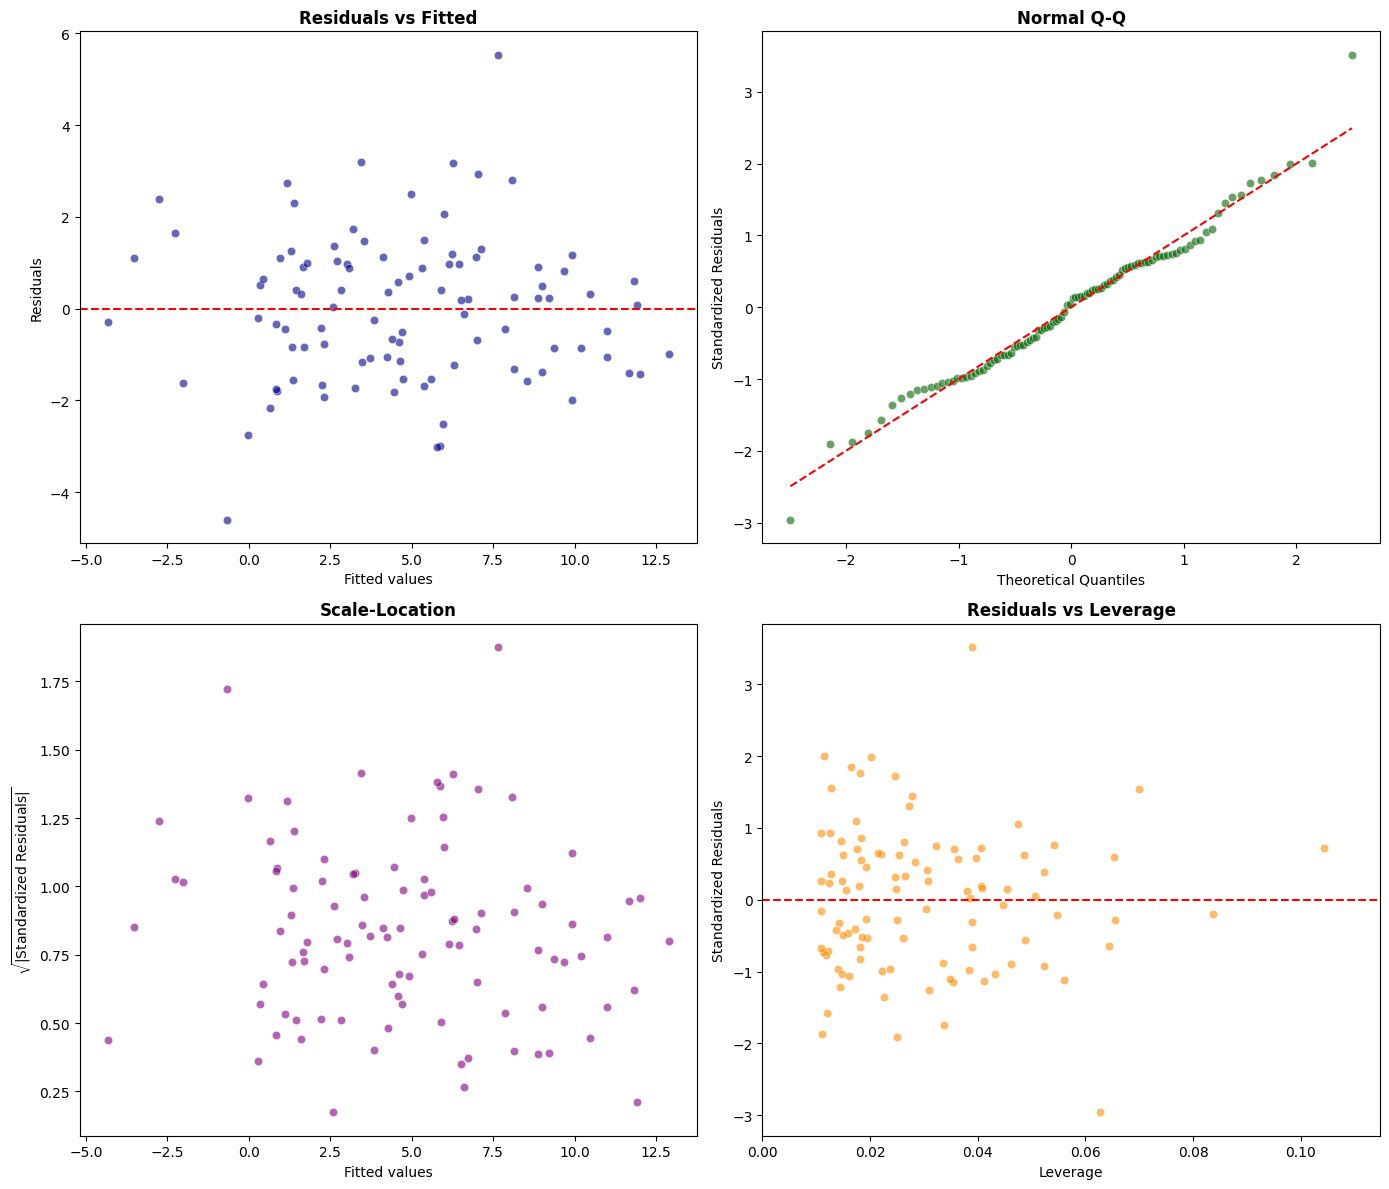

In [ ]:
# Case 1: Dùng Toy Data
print("KỊCH BẢN 1: Phương sai sai số không đổi")
residual_plots(X_toy_design, y_toy, beta_hat)

KỊCH BẢN 2: Phương sai sai số thay đổi (Heteroscedasticity)


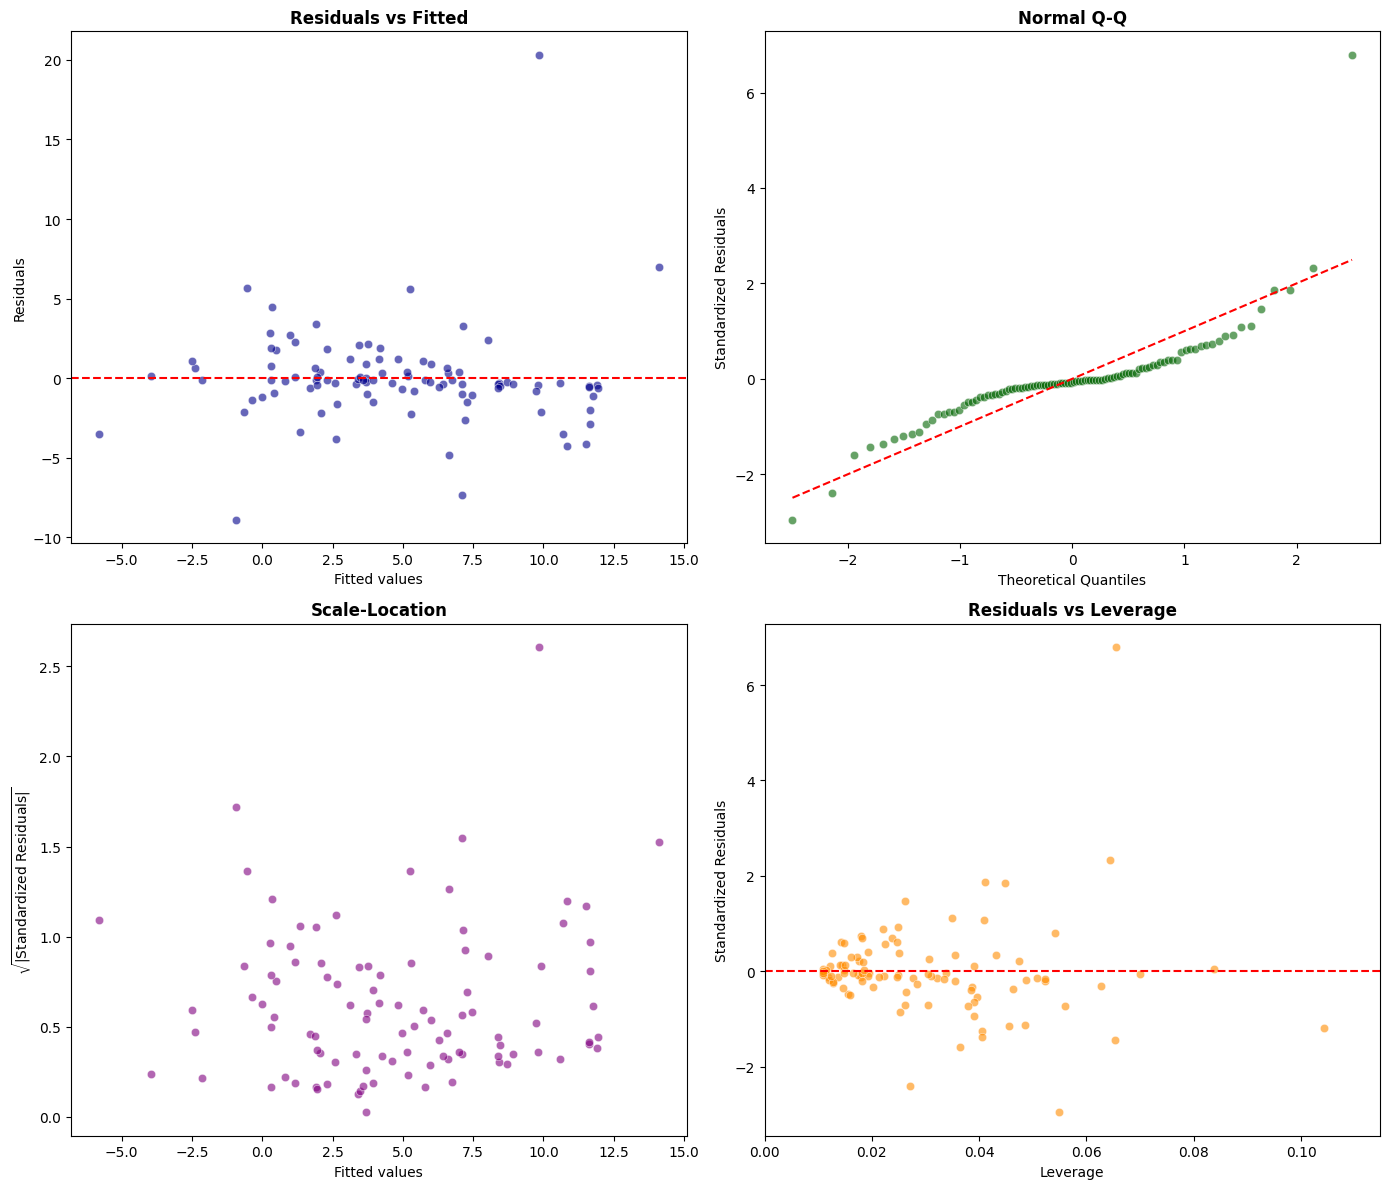

In [ ]:
# Case 2: Tạo Bad Data
noise_hetero = np.random.randn(n) * (X_toy[:, 0] ** 2) * 3  # Nhiễu phình to theo X1
y_bad = X_toy_design.dot(true_beta) + noise_hetero
beta_bad = (
    np.linalg.inv(X_toy_design.T.dot(X_toy_design)).dot(X_toy_design.T).dot(y_bad)
)

print("KỊCH BẢN 2: Phương sai sai số thay đổi (Heteroscedasticity)")
residual_plots(X_toy_design, y_bad, beta_bad)

* **Nhận xét Kịch bản 1:** Biểu đồ Normal Q-Q bám sát đường chéo, Scale-Location nằm ngang. Thỏa mãn các giả định Gauss-Markov.
* **Nhận xét Kịch bản 2:** Biểu đồ Scale-Location có hình cái phễu (toe ra ở đuôi). Suy ra hiện tượng Heteroscedasticity. Mô hình OLS lúc này dù không chệch nhưng không còn là BLUE (Best Linear Unbiased Estimator).

### 3. K-Fold Cross-Validation: Đánh giá mô hình & Phát hiện Overfitting

**1. Phân chia dữ liệu (Data Splitting):**
* Tập dữ liệu gốc có kích thước $n$ được chia thành $k$ phần (folds) rời rạc có kích thước xấp xỉ nhau: $S_1, S_2, \dots, S_k$.

**2. Vòng lặp K-Fold (Với mỗi fold $i$ từ $1$ đến $k$):**
* **Phân tách tập:** Chọn phần $S_i$ làm tập kiểm định (Validation set) chứa $m$ mẫu. Các phần còn lại $S \setminus S_i$ tạo thành tập huấn luyện (Train set).
* **Huấn luyện mô hình:** Ước lượng vector hệ số $\hat{\beta}^{(i)}$ trên tập Train bằng phương pháp OLS.
* **Dự đoán:** Tính vector giá trị dự đoán trên tập Validation: 
  $$\hat{y}_{val}^{(i)} = X_{val}^{(i)} \hat{\beta}^{(i)}$$
* **Tính lỗi của fold (Mean Squared Error - MSE):**
  $$MSE_i = \frac{1}{m} \sum_{j=1}^{m} \left( y_{val, j}^{(i)} - \hat{y}_{val, j}^{(i)} \right)^2$$

**3. Điểm đánh giá tổng hợp (CV Score):**
* Lỗi K-Fold CV là trung bình cộng của lỗi trên tất cả $k$ folds:
  $$CV\_Score = \frac{1}{k} \sum_{i=1}^k MSE_i$$

In [ ]:
# Tạo biến rác
X_garbage = np.random.randn(n, 5)
X_overfit = np.c_[X_toy, X_garbage]

# Chạy K-Fold (k=5)
cv_score_good = kfold_cv(X_toy, y_toy, k=5)
cv_score_overfit = kfold_cv(X_overfit, y_toy, k=5)

print(f"Mô hình 1 (Chỉ dùng biến đúng): CV RMSE = {cv_score_good:.4f}")
print(f"Mô hình 2 (Nhét thêm 5 biến rác): CV RMSE = {cv_score_overfit:.4f}")

Mô hình 1 (Chỉ dùng biến đúng): CV RMSE = 28.9198
Mô hình 2 (Nhét thêm 5 biến rác): CV RMSE = 32.3993


* **Nhận xét:** Mô hình 2 bị Overfitting nên điểm CV RMSE kém hơn hẳn (cao hơn) Mô hình 1, dù trên tập Train nó có thể có RSS nhỏ hơn. Hàm `kfold_cv` tự cài đặt đã hoạt động đúng bản chất trong việc đánh giá năng lực tổng quát hóa của mô hình.

### 4. Mô phỏng Monte Carlo định lý Gauss-Markov

In [ ]:
gauss_markov_simulation()

[{'beta_idx': 0,
  'true_val': 3.0,
  'E_ols': 3.006896967334199,
  'E_alt': 3.02387550420081,
  'Var_ols': 0.1532533019079362,
  'Var_alt': 0.28658221048207544},
 {'beta_idx': 1,
  'true_val': 1.5,
  'E_ols': 1.4994494544777401,
  'E_alt': 1.4955311050036375,
  'Var_ols': 0.004561119268229154,
  'Var_alt': 0.008014612779236409},
 {'beta_idx': 2,
  'true_val': -2.0,
  'E_ols': -2.000652657141561,
  'E_alt': -1.999388344596126,
  'Var_ols': 0.005224167222119239,
  'Var_alt': 0.00893235478333362}]